In [50]:
import particles_mod.Icosphere as ico
import numpy as np
import matplotlib.pyplot as plt
import libMobility as lm
import pyvista as pv
pv.set_jupyter_backend('html')




In [51]:
num_particles = 100

radius = 5.0

density = num_particles / (4.0 * np.pi * radius**2)

icosphere = ico.IcoSphere(radius, density)


13/06/2025 10:19:35 - VLMP - INFO - [VLMP] Starting VLMP 
13/06/2025 10:19:35 - VLMP - DEBUG - [VLMP] Processing "system" component ({'type': 'simulationName', 'parameters': {'simulationName': 'Icosphere'}}), type "simulationName" (VLMP.py:194)
13/06/2025 10:19:35 - VLMP - WARNING - [VLMP] (system) Component name not specified, using "simulationName". 
13/06/2025 10:19:35 - VLMP - DEBUG - [VLMP] (system) Component name "simulationName". (VLMP.py:200)
13/06/2025 10:19:35 - VLMP - DEBUG - [VLMP] (system) Component parameters "{'simulationName': 'Icosphere'}" (VLMP.py:207)
13/06/2025 10:19:35 - VLMP - DEBUG - [VLMP] Processing "system" component ({'type': 'simulationName', 'parameters': {'simulationName': 'Icosphere'}}), type "simulationName" (VLMP.py:194)
13/06/2025 10:19:35 - VLMP - WARNING - [VLMP] (system) Component name not specified, using "simulationName". 
13/06/2025 10:19:35 - VLMP - DEBUG - [VLMP] (system) Component name "simulationName". (VLMP.py:200)
13/06/2025 10:19:35 - VLMP

In [52]:

print("Number of particles:", icosphere.nparticles)
print("Radius of the icosphere:", icosphere.radius)

Number of particles: 92
Radius of the icosphere: 5.0


In [53]:
modes, eigenvalues = icosphere.obtain_modes()


Preliminary simulation structure created


[WARNING] UAMMD-structured Python wrapper is not compatible with UAMMD-structured self restarting mechanism


Read Hessian file /tmp/tmpilvgn_cb/hessian.txt with shape (8464, 11)


[MESSAGE] ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
[MESSAGE] ╻ ╻┏━┓┏┳┓┏┳┓╺┳┓
[MESSAGE] ┃ ┃┣━┫┃┃┃┃┃┃ ┃┃ Version: 2.5
[MESSAGE] ┗━┛╹ ╹╹ ╹╹ ╹╺┻┛
[MESSAGE] Compiled at: May 23 2025 13:23:39
[MESSAGE] Compiled in double precision mode
[MESSAGE] Computation started at Fri Jun 13 10:19:35 2025

[MESSAGE] [System] CUDA initialized
[MESSAGE] [System] Using device: NVIDIA GeForce RTX 3080 with id: 0
[MESSAGE] [System] Compute capability of the device: 8.6
[MESSAGE] ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ 
[MESSAGE] [ExtendedSystem] (system) Name: Icosphere
[MESSAGE] [ExtendedSystem] (system) Seed: 1749802775429123370
[MESSAGE] [GlobalDataBase] Fundamental not specified, using default fundamental, "Time"
[WARNING] [Time] No timeStep specified, using 0.0 as default.
[MESSAGE] [Basic] Loaded type A, mass: 1.000000, radius: 0.500000, charge: 0.000000
[MESSAGE] [ParticleData] Created with 92 particles.
[MESSAGE] [StateLoader] Loading property "id".
[MESSAGE] [St

In [54]:

def plot_positions(positions, radius=1.0):
    """
    Plot the positions of particles in 3D.
    Args:
        positions: Array of particle positions.
        radius: Radius of the spheres representing particles.
    """
    plotter = pv.Plotter()
    for pos in positions:
        sphere = pv.Sphere(radius=radius, center=pos)
        plotter.add_mesh(sphere, color='blue', opacity=0.5)
    plotter.window_size = [400, 400]
    plotter.show()

plot_positions(icosphere.positions, radius=1)


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [55]:

precision = np.float32 if lm.SelfMobility.precision == "float" else np.float64

def create_solver(model: str = "SelfMobility", wallHeight: float = 0.0):
    """
    Create a solver based on the specified model.
    Args:
        model: The model to use for the solver. Options are "SelfMobility" or "NBody".
    Returns:
        solver: An instance of the solver for the specified model.
    """

    if model == "SelfMobility":
        solver = lm.SelfMobility("open", "open", "open")
        solver.setParameters(5)
    elif model == "NBody":
        solver = lm.NBody("open", "open", "open")
        solver.setParameters()
    elif model == "NBodywall":
        solver = lm.NBody("open", "open", "single_wall")
        solver.setParameters(wallHeight = wallHeight)
    
    solver.initialize(
        temperature=0.0,
        viscosity=1/(6 * np.pi),
        hydrodynamicRadius=1.0,
        needsTorque=False,
    )
    return solver

def create_forces_from_modes(modes, eigenvalues):
    forces = - modes * eigenvalues.T
    return forces

def construct_coupling_matrix(modes, solver):
    coupling_matrix = np.zeros((icosphere.nparticles * 3, icosphere.nparticles * 3), dtype=precision)
    for mode_index in range(modes.shape[1]):
        force = modes[:, mode_index].reshape((icosphere.nparticles, 3))
        velocity = solver.Mdot(forces=force)[0]
        coupling_matrix[:, mode_index] = velocity.reshape((icosphere.nparticles * 3,))
    coupling_matrix = modes.T @ coupling_matrix
    return coupling_matrix
        
def plot_coupling_matrix(coupling_matrix, nummodes = 25):
    """
    Plot the mobility matrix as a heatmap.
    Args:
        coupling_matrix: The mobility matrix to plot.
    """
    plt.figure()
    plt.imshow(coupling_matrix[:nummodes,:nummodes], cmap='seismic', vmax=3, vmin=-3, 
               interpolation='None')
    plt.title("Mobility Matrix")
    plt.xlabel("Excitation modes")
    plt.ylabel("Excited modes")
    plt.colorbar()
    plt.show()

def plot_diagonal(coupling_matrix):
    """
    Plot the diagonal of the mobility matrix.
    Args:
        coupling_matrix: The mobility matrix to plot.
    """
    plt.scatter(range(coupling_matrix.shape[0]), coupling_matrix.diagonal(), s=1)
    plt.title("Diagonal of Mobility Matrix")
    plt.xlabel("Mode Index")
    plt.ylabel("Diagonal Value")
    plt.grid()

def plot_mode(positions : list, eigenmode: np.ndarray):
    """
    Plot the eigenmode of the Hessian matrix.
    :param positions: A list of tuples containing the x, y and z coordinates of each particle.
    :param eigenvectors: A numpy array containing the eigenmode data in (nparticles, 3) format.
    :param mode: The index of the eigenmode to plot.
    """

    new_positions = np.array(positions) + np.array(eigenmode)   # Scale the eigenmode for visualization

    mesh = pv.PolyData(new_positions)
    mesh = mesh.delaunay_3d()
    mesh['Eigenvector'] = eigenmode  # Add the eigenmode as a scalar field for coloring
    p = pv.Plotter()
    p.add_mesh(mesh, scalars='Eigenvector', show_scalar_bar=True, show_edges=False, cmap='coolwarm')
    p.add_arrows(np.array(positions), eigenmode / np.max(np.linalg.norm(eigenmode, axis=1))*2, color='blue', opacity=0.95
                 , name='Eigenvector Arrows')
    p.window_size = [300, 250]
    # add the coordinate triad bigger
    p.add_axes(interactive=True, line_width=5, labels_off=False, color='black')
    p.show()



positions = icosphere.positions.astype(precision)
assert positions.shape == (icosphere.nparticles, 3)

# forces = create_forces_from_modes(modes, eigenvalues)

# aux = modes.T @ forces + np.diag(eigenvalues)
# assert np.all(np.isclose(aux, 0.0, atol=1e-10)), "Auxiliary check failed, not close to zero."

# solver = create_solver("NBody")
# solver.setPositions(positions)

# coupling_matrix = construct_coupling_matrix(modes, solver)

# print("Coupling matrix symmetry check:", np.allclose(coupling_matrix, coupling_matrix.T, atol=1e-5))

# diagonal_values = coupling_matrix.diagonal()

#plot_coupling_matrix(np.abs(coupling_matrix-0*np.diag(diagonal_values)))


solver = create_solver("NBodywall", np.min(icosphere.positions[:, 2]) - 2.0)
#solver = create_solver("SelfMobility")
solver.setPositions(positions)

coupling_matrix = construct_coupling_matrix(modes, solver)

print("Coupling matrix symmetry check (wall):", np.allclose(coupling_matrix, coupling_matrix.T, atol=1e-5))


#plot_coupling_matrix(np.abs(coupling_matrix-0*np.diag(diagonal_values)))


coupling_eigenvalues, coupling_eigenvectors = np.linalg.eigh(coupling_matrix[:3, :3])
coupled_modes = modes[:, :3] @ coupling_eigenvectors
modes[:, :3] = coupled_modes

coupling_eigenvalues, coupling_eigenvectors = np.linalg.eigh(coupling_matrix[3:6, 3:6])
coupled_modes = modes[:, 3:6] @ coupling_eigenvectors
modes[:, 3:6] = coupled_modes


Coupling matrix symmetry check (wall): True


In [ ]:


solver = create_solver("NBodywall", np.min(icosphere.positions[:, 2]) - 100.01)
solver = create_solver("SelfMobility")
solver.setPositions(positions)
coupling_matrix = construct_coupling_matrix(modes, solver)


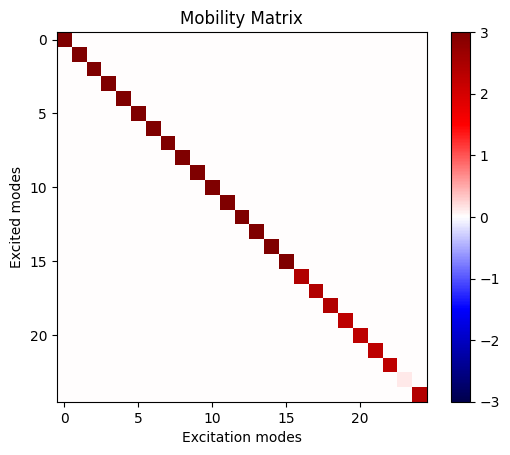

first 6 x 6 coupling matrix elements:
[[ 7.481  0.    -0.     0.    -0.     0.   ]
 [ 0.     7.481  0.    -0.     0.     0.   ]
 [-0.     0.     7.481 -0.     0.     0.   ]
 [ 0.    -0.    -0.    16.308 -0.     0.   ]
 [-0.     0.     0.     0.    16.801  0.   ]
 [ 0.     0.     0.    -0.    -0.    16.801]]


In [57]:
plot_coupling_matrix(np.abs(coupling_matrix), nummodes=25)

print("first 6 x 6 coupling matrix elements:")
np.set_printoptions(precision=3, suppress=True)
print(coupling_matrix[:6, :6])


In [58]:

for i in range(6):
    plot_mode(icosphere.positions, modes[:, i].reshape((icosphere.nparticles, 3)))

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

2025-06-13 10:19:38.007 (1395.129s) [    7FF7E46AB5C0]            vtkMath.cxx:570   WARN| Unable to factor linear system


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

2025-06-13 10:19:38.110 (1395.231s) [    7FF7E46AB5C0]      vtkDelaunay3D.cxx:513   WARN| vtkDelaunay3D (0x55980627a010): 8 degenerate triangles encountered, mesh quality suspect


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [59]:
plot_mode(icosphere.positions, modes[:, 23].reshape((icosphere.nparticles, 3)))

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

23
133


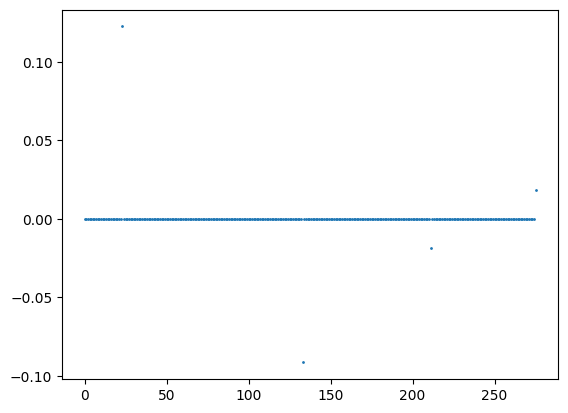

In [60]:
print(np.argmax(coupling_matrix[:, 23]))
print(np.argmax(-coupling_matrix[23, :]))
plt.figure()
plt.scatter(range(coupling_matrix.shape[0]), coupling_matrix[:, 23], s=1)
plt.show()

In [61]:
plot_mode(icosphere.positions, modes[:,136].reshape((icosphere.nparticles, 3)))

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…